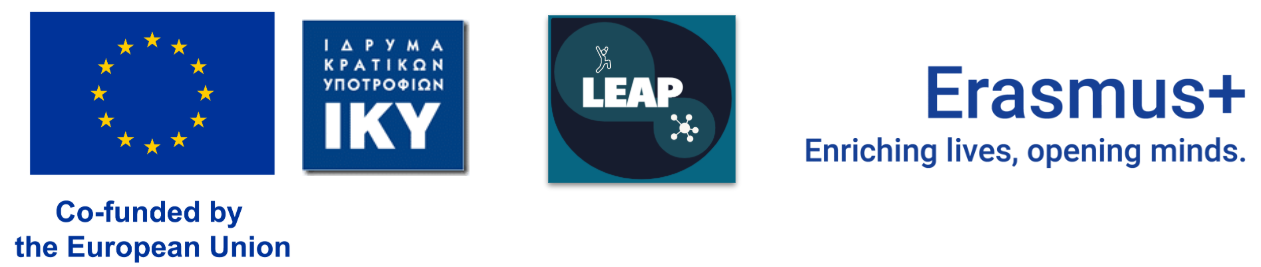

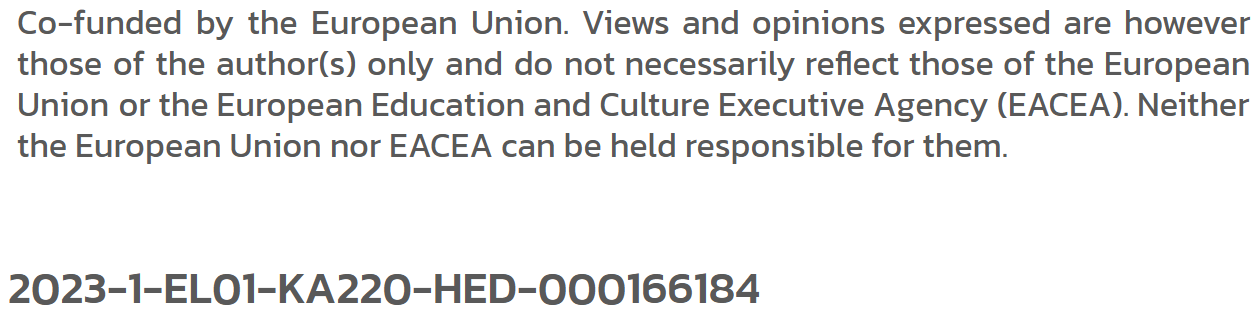

# Final Project, Option 3: How much structure can you find without the labels?

An agricultural co-op receives unlabelled deliveries of mixed wheat grain and wants to know how many distinct varieties are present, and how cleanly they separate, before committing to any sorting process. In this project you recover that structure using clustering alone.

In this project you take a data set with a known grouping, hide that grouping from yourself, and see how much of it you can recover using clustering alone. The labels are kept aside until the very end, where they serve only as an answer key.

**Central question:** how much of the real class structure can you recover without ever using the labels?

The data set is Seeds: 210 wheat kernels described by seven geometric measurements such as area, perimeter, and kernel length. You are given the measurements to work with, and the variety labels are set aside for the final check.

This project draws on Module 4. There we scaled features, reduced them with PCA, clustered with K-Means, chose the number of clusters using the elbow and silhouette methods, and validated the result against a known label with a cross-tabulation. Here you carry out that whole process yourself and judge how faithfully the clusters match the real varieties.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the scaling. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order, and resist looking at the varieties until Part D.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Loading the data

We download the Seeds data set. The seven measurements go into `X`, and the true varieties go into `y_true`. We put the varieties aside now and do not touch them until Part D, so that the clustering is done with no knowledge of the answer.

In [2]:
# The Seeds data set: 210 kernels described by seven geometric measurements.
# It is small and fully numeric,
# which suits clustering well.
feature_names = ["area", "perimeter", "compactness", "kernel_length",
                 "kernel_width", "asymmetry", "groove_length"]

seeds = fetch_openml(name="seeds", version=1, as_frame=True)

X = seeds.data.copy()
X.columns = feature_names          # give the seven measurements readable names

# The true varieties. We set these aside now and do NOT use them until Part D,
# where they serve only as an external check on the clustering.
y_true = seeds.target.to_numpy().astype(int)

print("Rows and features:", X.shape)
X.head()

Rows and features: (210, 7)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


### Scaling the features

Clustering relies on distances between points, so a feature measured on a larger scale would count for more than the others. We put every feature on the same footing with `StandardScaler`, as in Module 4.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix:", X_scaled.shape)

Scaled feature matrix: (210, 7)


## Part B. Explore, without labels

From here on, the cells are yours to complete.

First, look at the shape of the data. Seven measurements are too many to plot at once, so reduce them to two with PCA and draw a scatter. This is the same reduction you used in Module 4.

Explained variance ratio: [0.71874303 0.17108184]
Total variance captured by the two components: 89.0%


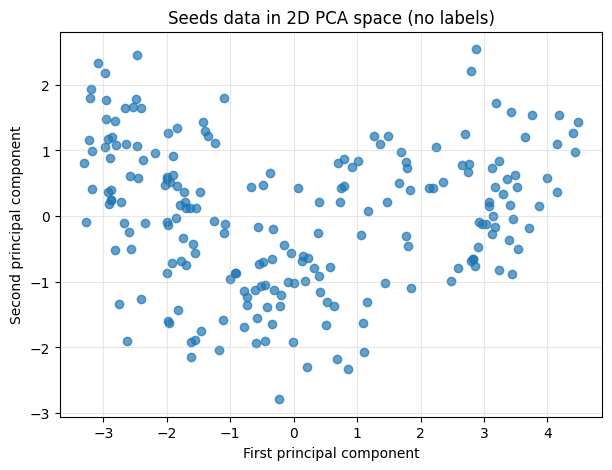

In [4]:
# Reduce the seven features to two so the data can be drawn on a flat plot.
pca = PCA(n_components=2)
X2 = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by the two components: {:.1%}".format(
    pca.explained_variance_ratio_.sum()))

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.7)
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.title("Seeds data in 2D PCA space (no labels)")
plt.grid(alpha=0.3)
plt.show()


### What do you see?

The single-colour scatter shows two clearly separated elongated clouds with a small gap between them, while a third group is blended into the right-hand cloud rather than fully separated. So the data suggest roughly three groups, but one of the boundaries is not clean in this 2D view, and the two principal components capture about 89% of the total variation, so this picture is a good but not perfect summary of the seven measurements.


## Part C. Cluster and choose the number of groups

Now decide how many clusters the data supports, using the two methods from Module 4. The elbow method looks at inertia, the total spread of points around their cluster centres, and finds where adding another cluster stops helping much. The silhouette score measures how well separated the clusters are, where higher is better.

k=2: inertia=659.17, silhouette=0.4658
k=3: inertia=430.66, silhouette=0.4007
k=4: inertia=371.30, silhouette=0.3276
k=5: inertia=326.51, silhouette=0.2849
k=6: inertia=289.80, silhouette=0.2798
k=7: inertia=262.97, silhouette=0.2709


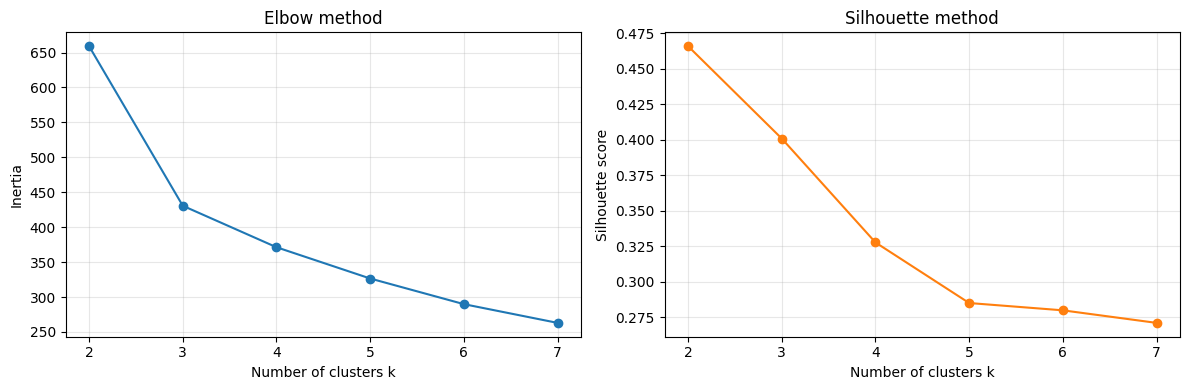

In [5]:
# Work out a sensible number of clusters.
ks = range(2, 8)
inertias = []
silhouettes = []

for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km_k.inertia_)
    sil = silhouette_score(X_scaled, km_k.labels_)
    silhouettes.append(sil)
    print(f"k={k}: inertia={km_k.inertia_:.2f}, silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ks, inertias, marker="o")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")
axes[0].grid(alpha=0.3)

axes[1].plot(ks, silhouettes, marker="o", color="tab:orange")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette method")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### How many clusters?

The two methods disagree: the elbow is at k = 3, where the inertia drop from 659 to 431 is large and then flattens sharply, while the silhouette is highest at k = 2 (0.47) and only slightly lower at k = 3 (0.40). I will use k = 3, because the silhouette penalty for the third cluster is small, the elbow clearly favours three, and the scatter in Part B also suggested a third group merged into the right-hand cloud.


### Fit K-Means

Fit K-Means at the number of clusters you decided on, and keep the cluster assignment for each kernel.

In [6]:
# Fit K-Means at the chosen number of clusters.
k = 3
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
labels = km.labels_

print("Cluster sizes:", np.bincount(labels))


Cluster sizes: [72 67 71]


## Part D. Judge against the labels

We now bring in the true varieties for the first time, only as an external check. The clustering itself is finished; nothing below changes it. We simply ask how well the groups you found line up with the real varieties, exactly as we validated the clusters in Module 4.

In [7]:
# Reveal the varieties only now, after the clustering is complete.
print("Varieties present:", np.unique(y_true))

# Cross-tabulate the cluster labels against the true varieties.
ct = pd.crosstab(labels, y_true)
print(ct)


Varieties present: [1 2 3]
col_0   1   2   3
row_0            
0       6   0  66
1       2  65   0
2      62   5   4


### Measuring the agreement

Turn the table into a single number with a purity score. For each cluster, take the count of its most common variety; add those counts across all clusters; then divide by the total number of kernels. A value near 1 means each cluster is almost entirely one variety.

Purity tends to increase when more clusters are created, so interpret it together with your chosen value of `k` and the cross-tabulation rather than using it on its own.

In [8]:
# Compute the purity score from `ct`.
purity = ct.max(axis=1).sum() / ct.values.sum()
print("Purity score: {:.3f}".format(purity))


Purity score: 0.919


### Back to the picture

Connect the numbers to the shape you saw earlier. Redraw the PCA scatter, but this time colour each point by its true variety. Interpret this picture cautiously: K-Means used all seven scaled features, while the plot shows only two PCA dimensions. Points that overlap here may still be separated by information in the other dimensions.

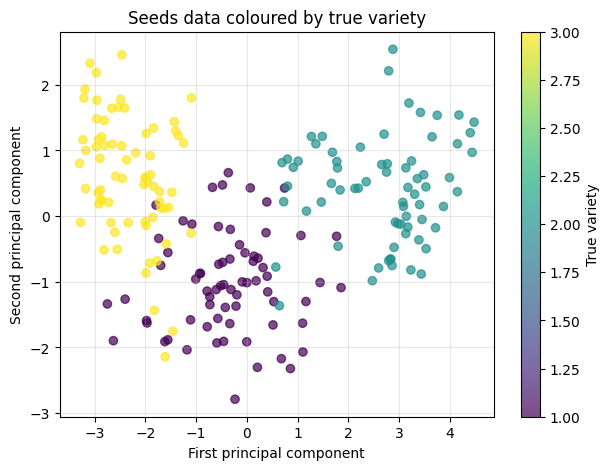

In [9]:
# Redraw the scatter of X2, now coloured by the true variety.
plt.figure(figsize=(7, 5))
sc = plt.scatter(X2[:, 0], X2[:, 1], c=y_true, cmap="viridis", alpha=0.7)
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.title("Seeds data coloured by true variety")
plt.colorbar(sc, label="True variety")
plt.grid(alpha=0.3)
plt.show()


### What each cluster captured

Finally, see what each cluster actually represents. The cluster centres are stored in scaled units, so turn them back into the original measurements with `scaler.inverse_transform`, and read across each row to picture the typical kernel in that group.

In [10]:
# Describe each cluster by its centre, in the original measurement units.
profiles = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_),
                        columns=feature_names)
print(profiles.round(2))


    area  perimeter  compactness  kernel_length  kernel_width  asymmetry  \
0  11.86      13.25         0.85           5.23          2.85       4.74   
1  18.50      16.20         0.88           6.18          3.70       3.63   
2  14.44      14.34         0.88           5.51          3.26       2.71   

   groove_length  
0           5.10  
1           6.04  
2           5.12  


### Ethical considerations

The main risk is reification: purity of 0.92 means the clusters match the official varieties well, but roughly one kernel in twelve is still placed in the wrong group, so a cluster is a strong hint about a delivery, not a certified variety label. If the co-op acted on the clusters alone, for example by pricing or sowing seed as if every member of a group were the same variety, about 8% of kernels would be mislabelled, and mistakes would concentrate on the boundary between varieties 1 and 3. The choice of k also matters: the silhouette actually preferred two groups, so presenting three clusters as a fact hides a genuine ambiguity; the honest claim is that the data support "about three groups, with one boundary somewhat blurred", and a costly sorting decision should be backed by expert labelling of at least a sample from each cluster.


## Wrapping up

The diagnostics supported three groups, chosen at k = 3 because the inertia elbow sits there while the silhouette, though highest at k = 2, was only marginally lower at k = 3; given the hint of a third group in the PCA scatter, three was the defensible choice. Judged against the true varieties, the clustering recovered most of the real structure: the cross-tabulation puts 65 of 67 variety-2 kernels, 62 of 70 variety-1 kernels and 66 of 73 variety-3 kernels into single clusters, for a purity of 0.92. Variety 2 (the largest kernels, with the longest grooves) was separated almost perfectly, while varieties 1 and 3 were the hardest to tell apart, each contributing a minority of kernels to the other's cluster. The coloured scatter supports this: variety 2 forms its own cloud, while varieties 1 and 3 overlap on the right-hand side, exactly where the confusion arises. Finally, this interpretation must stay cautious, because K-Means worked in all seven scaled dimensions while the plot shows only the two leading PCA components, which retain about 89% of the variance; points that look merged in 2D can be separated in the dimensions not shown, and conversely, so the plot is a useful check rather than proof.
